Train shape: (800, 2)
Test shape : (200, 2)


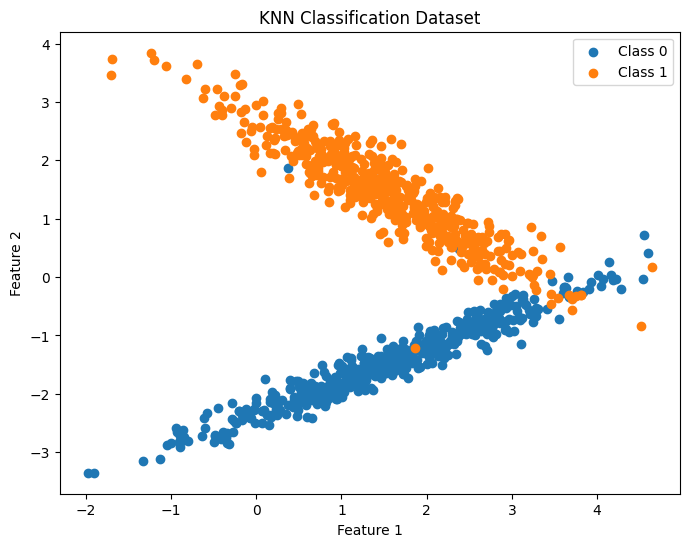


KNN Accuracy: 0.975

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       104
           1       0.98      0.97      0.97        96

    accuracy                           0.97       200
   macro avg       0.98      0.97      0.97       200
weighted avg       0.98      0.97      0.97       200



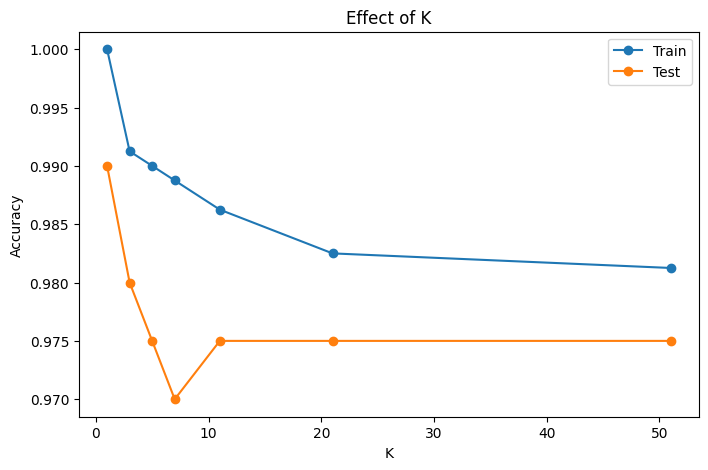


Uniform Accuracy: 0.975
Distance Accuracy: 0.985

Scaled KNN Accuracy: 0.985

Euclidean Accuracy: 0.975
Manhattan Accuracy: 0.99

KNN Regression MSE: 141.2370231679724
KNN Regression R²: 0.91280450852199


In [1]:
# ============================================================
# KNN — K-NEAREST NEIGHBORS 🟡
# ============================================================
#
# DEPTH:
#   🟡 Medium
#
# No scratch implementation required.
#
# Learn:
#   1. Why KNN?
#   2. Intuition
#   3. How KNN works
#   4. Distance
#   5. Choosing K
#   6. Classification
#   7. Regression
#   8. Feature scaling
#   9. Important parameters
#  10. sklearn implementation
#  11. Experiments
#  12. Advantages / disadvantages
#  13. Interview questions
#  14. 30-second explanation
#  15. Working tree
#
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    mean_squared_error,
    r2_score
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


# ============================================================
# 2. WHY KNN?
# ============================================================
#
# Suppose we have training points:
#
#
#       ● ● ●
#      ● ●
#
#
#                  ○ ○
#                 ○ ○ ○
#
#
# Now a new point arrives:
#
#              ?
#
#
# KNN asks:
#
# "Which training points are closest to this new point?"
#
# Then:
#
# Classification:
#     Look at the K nearest points
#     → majority vote
#
# Regression:
#     Look at the K nearest points
#     → average their values
#
#
# KNN is called:
#
#     Distance-based
#     Instance-based
#     Lazy learning
#
# ============================================================


# ============================================================
# 3. CORE INTUITION
# ============================================================
#
# KNN follows a very simple idea:
#
#     Similar points usually have similar outputs.
#
#
# Example:
#
# Suppose we want to classify a customer.
#
# We find the 5 most similar customers:
#
#     Customer 1 → Churn
#     Customer 2 → No Churn
#     Customer 3 → Churn
#     Customer 4 → Churn
#     Customer 5 → No Churn
#
#
# Votes:
#
#     Churn     = 3
#     No Churn  = 2
#
#
# Prediction:
#
#     Churn
#
# ============================================================


# ============================================================
# 4. KNN IS A LAZY LEARNING ALGORITHM ⭐
# ============================================================
#
# Most ML algorithms learn parameters during training.
#
# Example:
#
# Linear Regression:
#
#     Training
#         ↓
#     Learn weights
#         ↓
#     Prediction
#
#
# KNN:
#
#     Training
#         ↓
#     Mostly store the training data
#         ↓
#     Prediction
#         ↓
#     Calculate distances
#         ↓
#     Find nearest neighbors
#
#
# Therefore:
#
# Training is cheap.
#
# Prediction can be expensive.
#
# ============================================================


# ============================================================
# 5. HOW KNN WORKS ⭐⭐⭐
# ============================================================
#
# Given a new point X:
#
#
# Step 1:
#     Calculate distance from X to every training point.
#
# Step 2:
#     Sort points by distance.
#
# Step 3:
#     Select K closest points.
#
# Step 4:
#
#     Classification:
#         Majority vote
#
#     Regression:
#         Average / weighted average
#
#
# Step 5:
#     Return prediction.
#
# ============================================================


# ============================================================
# 6. DISTANCE — EUCLIDEAN DISTANCE ⭐⭐⭐
# ============================================================
#
# Most common distance:
#
# Euclidean distance.
#
#
# For two points:
#
#     A = (x1, x2)
#     B = (y1, y2)
#
#
# Distance:
#
#     d(A,B)
#
#       = sqrt(
#           (x1-y1)^2
#           +
#           (x2-y2)^2
#         )
#
#
# Example:
#
# A = (1, 2)
# B = (4, 6)
#
#
# d = sqrt(
#       (1-4)^2
#       +
#       (2-6)^2
#     )
#
#   = sqrt(
#       9 + 16
#     )
#
#   = sqrt(25)
#
#   = 5
#
# ============================================================


# ============================================================
# 7. OTHER DISTANCE METRICS
# ============================================================
#
#
# 1. Euclidean
#
#     Straight-line distance.
#
#
# 2. Manhattan
#
#     d = |x1-y1| + |x2-y2| + ...
#
#     Useful when movement is along axes/grid-like paths.
#
#
# 3. Minkowski
#
#     General form:
#
#     d =
#     (sum |xi-yi|^p)^(1/p)
#
#
#     p = 1 → Manhattan
#     p = 2 → Euclidean
#
#
# 4. Hamming
#
#     Number/fraction of positions that differ.
#
#     Useful for categorical/binary representations.
#
#
# 5. Cosine distance
#
#     Based on angle between vectors.
#
#     Common for text/vector representations.
#
# ============================================================


# ============================================================
# 8. CREATE CLASSIFICATION DATA
# ============================================================

X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.5,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)


# ============================================================
# 9. VISUALIZE DATA
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    label="Class 0"
)

plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    label="Class 1"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("KNN Classification Dataset")

plt.legend()
plt.show()


# ============================================================
# 10. BASIC KNN CLASSIFIER
# ============================================================

knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(
    X_train,
    y_train
)

pred = knn.predict(X_test)

print(
    "\nKNN Accuracy:",
    accuracy_score(y_test, pred)
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        pred
    )
)


# ============================================================
# 11. WHAT HAPPENS DURING PREDICTION?
# ============================================================
#
# Suppose:
#
#     K = 5
#
# New point:
#
#             ?
#
#
# Find distances:
#
#     Point A → 0.5
#     Point B → 0.8
#     Point C → 1.1
#     Point D → 1.4
#     Point E → 1.7
#     Point F → 2.8
#
#
# Select 5 nearest:
#
#     A B C D E
#
#
# Their labels:
#
#     A → 1
#     B → 1
#     C → 0
#     D → 1
#     E → 0
#
#
# Votes:
#
#     Class 1 → 3
#     Class 0 → 2
#
#
# Prediction:
#
#     Class 1
#
# ============================================================


# ============================================================
# 12. WHAT DOES K MEAN? ⭐⭐⭐
# ============================================================
#
# K = number of nearest neighbors used.
#
#
# Small K:
#
#     K = 1
#
#     Very local decision.
#
#     Can be sensitive to noise.
#
#     High variance.
#
#
# Large K:
#
#     Uses more points.
#
#     Smoother decision boundary.
#
#     Can ignore local patterns.
#
#     High bias.
#
#
# Easy memory:
#
#
#     Small K
#         ↓
#     Complex boundary
#         ↓
#     Possible overfitting
#
#
#     Large K
#         ↓
#     Smooth boundary
#         ↓
#     Possible underfitting
#
# ============================================================


# ============================================================
# 13. EXPERIMENT — DIFFERENT K VALUES
# ============================================================

k_values = [1, 3, 5, 7, 11, 21, 51]

train_scores = []
test_scores = []

for k in k_values:

    model = KNeighborsClassifier(
        n_neighbors=k
    )

    model.fit(
        X_train,
        y_train
    )

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_scores.append(
        accuracy_score(
            y_train,
            train_pred
        )
    )

    test_scores.append(
        accuracy_score(
            y_test,
            test_pred
        )
    )


plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    train_scores,
    marker="o",
    label="Train"
)

plt.plot(
    k_values,
    test_scores,
    marker="o",
    label="Test"
)

plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("Effect of K")

plt.legend()
plt.show()


# ============================================================
# 14. WEIGHTS — UNIFORM vs DISTANCE
# ============================================================
#
# KNN can give every neighbor equal importance.
#
# weights="uniform"
#
# Example:
#
#     Neighbor 1 → weight 1
#     Neighbor 2 → weight 1
#     Neighbor 3 → weight 1
#
#
# Or use:
#
# weights="distance"
#
# Closer points get more importance.
#
#
# Example:
#
#     Point A → distance 0.2 → high weight
#     Point B → distance 1.5 → lower weight
#
# ============================================================


# Uniform weights

knn_uniform = KNeighborsClassifier(
    n_neighbors=5,
    weights="uniform"
)

knn_uniform.fit(
    X_train,
    y_train
)

pred_uniform = knn_uniform.predict(
    X_test
)

print(
    "\nUniform Accuracy:",
    accuracy_score(
        y_test,
        pred_uniform
    )
)


# Distance weights

knn_distance = KNeighborsClassifier(
    n_neighbors=5,
    weights="distance"
)

knn_distance.fit(
    X_train,
    y_train
)

pred_distance = knn_distance.predict(
    X_test
)

print(
    "Distance Accuracy:",
    accuracy_score(
        y_test,
        pred_distance
    )
)


# ============================================================
# 15. FEATURE SCALING ⭐⭐⭐
# ============================================================
#
# KNN is VERY sensitive to feature scale.
#
#
# Example:
#
# Feature 1:
#     Age = 20 - 60
#
# Feature 2:
#     Salary = 20,000 - 2,00,000
#
#
# Euclidean distance:
#
#     salary differences can dominate the distance.
#
#
# Therefore:
#
#     StandardScaler
#           ↓
#          KNN
#
#
# StandardScaler:
#
#     mean = 0
#     std  = 1
#
# ============================================================


# ============================================================
# 16. KNN WITH SCALING
# ============================================================

scaled_knn = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),

    (
        "knn",
        KNeighborsClassifier(
            n_neighbors=5
        )
    )
])

scaled_knn.fit(
    X_train,
    y_train
)

scaled_pred = scaled_knn.predict(
    X_test
)

print(
    "\nScaled KNN Accuracy:",
    accuracy_score(
        y_test,
        scaled_pred
    )
)


# ============================================================
# 17. IMPORTANT KNN PARAMETERS
# ============================================================
#
#
# ------------------------------------------------------------
# n_neighbors ⭐⭐⭐
# ------------------------------------------------------------
#
# Number of neighbors K.
#
# Small:
#     flexible
#     sensitive to noise
#
# Large:
#     smoother
#     may underfit
#
#
# ------------------------------------------------------------
# weights ⭐⭐⭐
# ------------------------------------------------------------
#
# "uniform"
#     Every neighbor has equal weight.
#
# "distance"
#     Closer neighbors have greater influence.
#
#
# ------------------------------------------------------------
# metric ⭐⭐⭐
# ------------------------------------------------------------
#
# Distance function.
#
# Examples:
#
# "minkowski"
# "euclidean"
# "manhattan"
#
#
# ------------------------------------------------------------
# p
# ------------------------------------------------------------
#
# Parameter for Minkowski distance.
#
# p = 1
#     Manhattan
#
# p = 2
#     Euclidean
#
#
# ------------------------------------------------------------
# algorithm
# ------------------------------------------------------------
#
# How nearest neighbors are searched.
#
# Options:
#
# "auto"
# "ball_tree"
# "kd_tree"
# "brute"
#
#
# auto:
#     sklearn chooses an appropriate method.
#
#
# ------------------------------------------------------------
# leaf_size
# ------------------------------------------------------------
#
# Controls leaf size for KD Tree / Ball Tree.
#
# Mostly affects computational performance.
#
#
# ------------------------------------------------------------
# n_jobs
# ------------------------------------------------------------
#
# Number of CPU jobs for neighbor search.
#
# n_jobs=-1
#     Use all available CPU cores.
#
# ============================================================


# ============================================================
# 18. DIFFERENT DISTANCE METRICS
# ============================================================

# Euclidean distance
knn_euclidean = KNeighborsClassifier(
    n_neighbors=5,
    metric="euclidean"
)

knn_euclidean.fit(
    X_train,
    y_train
)

print(
    "\nEuclidean Accuracy:",
    accuracy_score(
        y_test,
        knn_euclidean.predict(X_test)
    )
)


# Manhattan distance
knn_manhattan = KNeighborsClassifier(
    n_neighbors=5,
    metric="manhattan"
)

knn_manhattan.fit(
    X_train,
    y_train
)

print(
    "Manhattan Accuracy:",
    accuracy_score(
        y_test,
        knn_manhattan.predict(X_test)
    )
)


# ============================================================
# 19. KNN REGRESSION
# ============================================================
#
# KNN can also be used for regression.
#
# Classification:
#
#     Majority vote
#
#
# Regression:
#
#     Average target values of neighbors
#
# ============================================================

X_reg, y_reg = make_regression(
    n_samples=1000,
    n_features=2,
    noise=10,
    random_state=42
)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)


# ============================================================
# 20. KNN REGRESSOR
# ============================================================

knn_reg = KNeighborsRegressor(
    n_neighbors=5
)

knn_reg.fit(
    X_train_r,
    y_train_r
)

reg_pred = knn_reg.predict(
    X_test_r
)

print(
    "\nKNN Regression MSE:",
    mean_squared_error(
        y_test_r,
        reg_pred
    )
)

print(
    "KNN Regression R²:",
    r2_score(
        y_test_r,
        reg_pred
    )
)


# ============================================================
# 21. KNN CLASSIFICATION vs REGRESSION
# ============================================================
#
#
# Classification:
#
#     Find K neighbors
#          ↓
#     Majority vote
#          ↓
#     Class
#
#
# Regression:
#
#     Find K neighbors
#          ↓
#     Average target values
#          ↓
#     Numeric prediction
#
# ============================================================


# ============================================================
# 22. CURSE OF DIMENSIONALITY ⭐⭐⭐
# ============================================================
#
# KNN depends on distance.
#
# As the number of dimensions increases:
#
#     Points become increasingly spread out.
#
# Distances between points can become less meaningful.
#
#
# This is called:
#
#     CURSE OF DIMENSIONALITY
#
#
# Example:
#
# 2 features:
#
#     distances are useful
#
# 1000 features:
#
#     many points may appear similarly far away
#
#
# Therefore KNN can perform poorly in very
# high-dimensional spaces.
#
#
# Solutions can include:
#
#     Feature selection
#     PCA
#     Dimensionality reduction
#
# ============================================================


# ============================================================
# 23. KNN — ADVANTAGES
# ============================================================
#
# 1. Very simple concept.
#
# 2. Almost no training time.
#
# 3. Can model nonlinear decision boundaries.
#
# 4. Works for classification and regression.
#
# 5. No assumptions about the underlying distribution.
#
# ============================================================


# ============================================================
# 24. KNN — DISADVANTAGES
# ============================================================
#
# 1. Prediction can be expensive.
#
# 2. Sensitive to feature scaling.
#
# 3. Sensitive to irrelevant features.
#
# 4. Suffers from curse of dimensionality.
#
# 5. Requires storing training data.
#
# 6. Choosing K and distance metric matters.
#
# ============================================================


# ============================================================
# 25. KNN vs SVM
# ============================================================
#
# KNN:
#
#     Instance-based
#     Distance-based
#     No explicit decision boundary during training
#
#
# SVM:
#
#     Model-based
#     Learns decision boundary
#     Uses margin / kernels
#
#
# KNN:
#
#     Training cheap
#     Prediction expensive
#
#
# SVM:
#
#     Training generally more expensive
#     Prediction uses learned model
#
# ============================================================


# ============================================================
# 26. KNN vs K-MEANS
# ============================================================
#
# IMPORTANT:
#
# KNN and K-Means are completely different.
#
#
# KNN:
#
#     Supervised
#     Uses labeled data
#     Classification / Regression
#
#
# K-Means:
#
#     Unsupervised
#     No labels required
#     Clustering
#
#
# KNN:
#
#     K = number of neighbors
#
#
# K-Means:
#
#     K = number of clusters
#
# ============================================================


# ============================================================
# 27. INTERVIEW QUESTIONS
# ============================================================
#
#
# Q1. What is KNN?
#
# Answer:
#
# KNN is a supervised, instance-based learning algorithm
# that predicts a sample using the labels or target values
# of its nearest training examples.
#
#
# ------------------------------------------------------------
#
# Q2. Why is KNN called lazy learning?
#
# Answer:
#
# Because it does not learn a complex model during training.
# It mainly stores the training data and performs the main
# computation during prediction.
#
#
# ------------------------------------------------------------
#
# Q3. How does KNN classification work?
#
# Answer:
#
# Calculate distances, select K nearest points and use
# majority voting to determine the class.
#
#
# ------------------------------------------------------------
#
# Q4. How does KNN regression work?
#
# Answer:
#
# Calculate distances, select K nearest points and average
# their target values.
#
#
# ------------------------------------------------------------
#
# Q5. What happens when K is too small?
#
# Answer:
#
# The model becomes very sensitive to noise and can
# overfit.
#
#
# ------------------------------------------------------------
#
# Q6. What happens when K is too large?
#
# Answer:
#
# The model becomes too smooth and can underfit.
#
#
# ------------------------------------------------------------
#
# Q7. Why is feature scaling important?
#
# Answer:
#
# KNN uses distance, so a feature with a larger numerical
# scale can dominate the distance calculation.
#
#
# ------------------------------------------------------------
#
# Q8. What is the curse of dimensionality?
#
# Answer:
#
# As dimensionality increases, distance-based comparisons
# become less informative, making algorithms such as KNN
# less effective.
#
#
# ------------------------------------------------------------
#
# Q9. What is the difference between uniform and distance
# weighting?
#
# Answer:
#
# Uniform weighting gives every neighbor equal importance.
# Distance weighting gives closer neighbors more influence.
#
#
# ------------------------------------------------------------
#
# Q10. KNN vs K-Means?
#
# Answer:
#
# KNN is supervised and uses labeled examples for prediction.
# K-Means is unsupervised and groups unlabeled examples into
# clusters.
#
#
# ============================================================


# ============================================================
# 28. 30-SECOND INTERVIEW EXPLANATION ⭐⭐⭐
# ============================================================
#
# KNN is a supervised, instance-based learning algorithm.
# During prediction, it calculates the distance between the
# new sample and training samples, selects the K nearest
# neighbors and uses majority voting for classification or
# averaging for regression.
#
# The important parameters are K, distance metric and
# weighting. KNN is sensitive to feature scaling and can
# suffer from the curse of dimensionality.
#
# ============================================================


# ============================================================
# 29. FINAL MEMORY CHEATSHEET
# ============================================================
#
# KNN =
#
# New point
#     ↓
# Calculate distances
#     ↓
# Find K nearest points
#     ↓
# ┌───────────────────┐
# │ Classification     │
# │ → Majority vote    │
# └───────────────────┘
#
# OR
#
# ┌───────────────────┐
# │ Regression         │
# │ → Average target   │
# └───────────────────┘
#
#
# MUST REMEMBER:
#
# 1. Instance-based
#
# 2. Lazy learning
#
# 3. Distance-based
#
# 4. K = number of neighbors
#
# 5. Small K → possible overfitting
#
# 6. Large K → possible underfitting
#
# 7. Feature scaling is important
#
# 8. Euclidean is common
#
# 9. weights="distance" gives closer points more influence
#
# 10. Curse of dimensionality
#
# ============================================================


# ============================================================
# 30. WORKING TREE ⭐⭐⭐
# ============================================================
#
#
#                         KNN
#                          │
#                          ▼
#                    New Data Point
#                          │
#                          ▼
#              Calculate Distance From
#              Training Data Points
#                          │
#                          ▼
#                    Sort by Distance
#                          │
#                          ▼
#                    Select K Neighbors
#                          │
#                ┌─────────┴─────────┐
#                │                   │
#                ▼                   ▼
#          Classification        Regression
#                │                   │
#                ▼                   ▼
#          Majority Vote        Average Values
#                │                   │
#                └─────────┬─────────┘
#                          │
#                          ▼
#                       Prediction
#
#
# ============================================================
#
# DISTANCE TREE:
#
# New Point
#     │
#     ▼
# Choose Distance Metric
#     │
#     ├── Euclidean
#     │
#     ├── Manhattan
#     │
#     └── Minkowski
#     │
#     ▼
# Calculate Distance
#     │
#     ▼
# Sort Points
#     │
#     ▼
# Select K
#     │
#     ▼
# Prediction
#
#
# ============================================================
#
# COMPLETE MENTAL MODEL:
#
#                 Training Data
#                      │
#                      │
#                      ▼
#               Store Examples
#                      │
#                      │
#                New Data Point
#                      │
#                      ▼
#                Feature Scaling
#                      │
#                      ▼
#               Calculate Distance
#                      │
#                      ▼
#                Find Nearest K
#                      │
#             ┌────────┴────────┐
#             │                 │
#             ▼                 ▼
#       Classification      Regression
#             │                 │
#             ▼                 ▼
#       Majority Vote       Average / Weighted
#             │                 │
#             └────────┬────────┘
#                      ▼
#                  Prediction
#
# ============================================================